# Step 14 — SHAP Model Explainability
### Credit Risk Prediction — Lending Club Dataset

Continues from **Step 9** (tuned models via `GridSearchCV`) and **Step 10** (final test-set evaluation).

**Goal:** understand which *structured* credit-risk features drive the predictions of the finalized
**Decision Tree** — `preprocessing → SMOTE → DecisionTreeClassifier` — on the untouched test set.

**This notebook does:**
- reuse the finalized Step 9 Decision Tree pipeline (same preprocessing, same SMOTE step, same hyperparameters)
- transform `X_test` with the *fitted* preprocessing component and recover the real post-one-hot feature names
- apply `shap.TreeExplainer` to the fitted `DecisionTreeClassifier`
- report global importance, a summary plot, feature direction, one individual explanation, and a business interpretation
- verify dimensions, name alignment, finiteness, additivity, and that the explained model is the finalized Step 9 tree

**This notebook does NOT:**
- tune anything, or add any model
- use the text / TF-IDF features, the Step 13 combined model, or the Step 8 diagnostic SMOTE arrays
- add feature engineering, NLP, or GenAI
- change the split (`train_test_split(test_size=0.20, stratify=target, random_state=42)`)

**Ground rules for reading the results**
1. SHAP describes what **this fitted model** does with its inputs — it is a statement about *model association*, not about real-world causation.
2. SHAP values here are in **probability units of P(Bad)**; they are reported in percentage points (pp).
3. The tree was trained on **SMOTE-balanced** data, so its probabilities are *not* calibrated default rates (see Section 4).

## 0. Setup

In [1]:
# Ensure shap and imbalanced-learn are available (Colab does not ship them by default)
try:
    import shap
except ImportError:
    %pip install -q shap
    import shap

try:
    import imblearn
except ImportError:
    %pip install -q imbalanced-learn
    import imblearn

print("shap version:           ", shap.__version__)
print("imbalanced-learn version:", imblearn.__version__)

shap version:            0.52.0
imbalanced-learn version: 0.14.2


In [2]:
import os

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    if not os.path.ismount('/content/drive'):
        drive.mount('/content/drive')
    else:
        print("Drive already mounted.")
    PROJECT_DIR = '/content/drive/MyDrive/Credit_Risk_LendingClub'
else:
    PROJECT_DIR = os.getcwd()          # local run: use the working directory

os.makedirs(PROJECT_DIR, exist_ok=True)
OUTPUT_DIR = os.path.join(PROJECT_DIR, 'step14_shap_outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("PROJECT_DIR:", PROJECT_DIR)
print("OUTPUT_DIR: ", OUTPUT_DIR)

Mounted at /content/drive
PROJECT_DIR: /content/drive/MyDrive/Credit_Risk_LendingClub
OUTPUT_DIR:  /content/drive/MyDrive/Credit_Risk_LendingClub/step14_shap_outputs


## 1. Reproduce the Step 7 split and preprocessing definition

Identical to Steps 9 and 10 (`random_state=42`, same feature lists, same `ColumnTransformer` definition), so
`X_train` / `X_test` are the same rows as before. `X_test` is used here only for inference and explanation.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from scipy.stats import spearmanr

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, roc_auc_score, average_precision_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)

_candidates = [
    os.path.join(PROJECT_DIR, "credit_risk_step6_final.csv"),
    "credit_risk_step6_final.csv",
    "credit_final.csv",
]
DATA_PATH = next((p for p in _candidates if os.path.exists(p)), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Step 6 CSV not found in PROJECT_DIR or the working directory. "
        "Upload/copy it there, then re-run this cell."
    )

df = pd.read_csv(DATA_PATH, low_memory=False)
df['issue_d'] = pd.to_datetime(df['issue_d'])
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'])
assert df.shape == (41988, 37), f"Unexpected shape: {df.shape}"

RANDOM_STATE = 42
train_df, test_df = train_test_split(
    df, test_size=0.20, stratify=df['target'], random_state=RANDOM_STATE
)

NON_FEATURE_COLS = ['target', 'issue_d', 'earliest_cr_line']
X_train = train_df.drop(columns=NON_FEATURE_COLS)
y_train = train_df['target'].copy()
X_test = test_df.drop(columns=NON_FEATURE_COLS)
y_test = test_df['target'].copy()

numerical_features = [
    'loan_amnt', 'term', 'int_rate', 'installment', 'annual_inc', 'dti',
    'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record',
    'open_acc', 'revol_bal', 'revol_util', 'total_acc', 'delinq_amnt',
    'pub_rec_bankruptcies', 'credit_history_months', 'loan_to_income',
    'installment_to_income', 'revol_bal_to_income', 'open_acc_ratio',
    'fico_avg', 'grade_ordinal', 'emp_length_years',
    'has_public_record', 'has_delinquency', 'pub_rec_bankruptcies_missing',
    'revol_util_missing', 'emp_length_missing', 'is_income_verified'
]
categorical_features = [
    'verification_status', 'addr_state', 'dti_bin',
    'home_ownership_grouped', 'purpose_grouped'
]
assert set(numerical_features) | set(categorical_features) == set(X_train.columns)

numeric_pipe = Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))])
categorical_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipe, numerical_features),
    ('cat', categorical_pipe, categorical_features),
])

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape, " <- untouched; used ONLY for inference / explanation here")
print("y_train shape:", y_train.shape)
print("y_test shape: ", y_test.shape)
print(f"Bad-loan rate: train={y_train.mean():.4f}, test={y_test.mean():.4f}")

X_train shape: (33590, 34)
X_test shape:  (8398, 34)  <- untouched; used ONLY for inference / explanation here
y_train shape: (33590,)
y_test shape:  (8398,)
Bad-loan rate: train=0.1528, test=0.1528


## 2. The finalized Step 9 Decision Tree

**Recovery of the fitted model.** Neither Step 9 nor Step 10 persisted a model file (Step 10 says so explicitly and
re-derived the estimator). This section therefore does one of two things, in order:

1. **If** `step9_best_decision_tree.joblib` exists in `PROJECT_DIR`, load it — that is the literal Step 9 object.
2. **Otherwise** rebuild the *same* `preprocessing → SMOTE → DecisionTreeClassifier` pipeline, set the **recorded Step 9
   `best_params_`**, and fit it once on the original `X_train` / `y_train`. This is exactly what `GridSearchCV(refit=True)`
   does as its last step. **No search is run and nothing is tuned**; every random state is fixed at 42, so the fit is deterministic.

Either way, Section 5 proves the object matches Step 9 / Step 10 (hyperparameters, and the reported test-set
confusion matrix, ROC-AUC and PR-AUC). *To make later runs use the literal object, run
`joblib.dump(grid_dt.best_estimator_, '<PROJECT_DIR>/step9_best_decision_tree.joblib')` at the end of Step 9/10.*

In [4]:
# Recorded Step 9 result (Model B, Decision Tree) — copied from the Step 9 notebook output.
STEP9_DT_BEST_PARAMS = {
    'classifier__criterion': 'entropy',
    'classifier__max_depth': 8,
    'classifier__min_samples_leaf': 5,
    'classifier__min_samples_split': 2,
}
MODEL_PATH = os.path.join(PROJECT_DIR, 'step9_best_decision_tree.joblib')

if os.path.exists(MODEL_PATH):
    best_dt = joblib.load(MODEL_PATH)
    MODEL_SOURCE = f"loaded persisted estimator: {MODEL_PATH}"
else:
    pipeline_dt = ImbPipeline(steps=[
        ('preprocessing', clone(preprocessor)),          # unfitted copy of the Step 7 definition (as in Step 9)
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('classifier', DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ])
    best_dt = pipeline_dt.set_params(**STEP9_DT_BEST_PARAMS)
    best_dt.fit(X_train, y_train)          # same fit GridSearchCV(refit=True) performs; X_test is never passed in
    joblib.dump(best_dt, MODEL_PATH)
    MODEL_SOURCE = "rebuilt from recorded Step 9 best_params_ and fitted once on X_train/y_train (no search)"

print("Model source:", MODEL_SOURCE)
print()
print("Pipeline steps:")
for name, step in best_dt.steps:
    print(f"  {name:14s} -> {type(step).__name__}")

# Predictions exactly as in Step 10 (imblearn skips SMOTE at predict time)
y_pred_dt = best_dt.predict(X_test)
y_proba_dt = best_dt.predict_proba(X_test)[:, 1]
print()
print("Predictions on X_test:", y_pred_dt.shape, y_proba_dt.shape)

Model source: rebuilt from recorded Step 9 best_params_ and fitted once on X_train/y_train (no search)

Pipeline steps:
  preprocessing  -> ColumnTransformer
  smote          -> SMOTE
  classifier     -> DecisionTreeClassifier

Predictions on X_test: (8398,) (8398,)


## 3. Transform the test set with the fitted preprocessing component and recover feature names

The explainer must see the same columns the tree was trained on. We pull the **already-fitted** `ColumnTransformer` and the
**already-fitted** `DecisionTreeClassifier` out of the finalized pipeline — no refit of either — and transform `X_test`.

`get_feature_names_out()` gives the true post-one-hot names (e.g. `cat__addr_state_CA`); the `num__` / `cat__` prefixes
are stripped for readability, and each one-hot column is mapped back to its source feature (`feature_group`) so importance can
also be reported per original feature.

In [5]:
fitted_pre = best_dt.named_steps['preprocessing']     # fitted ColumnTransformer (fit on X_train only)
clf = best_dt.named_steps['classifier']               # fitted DecisionTreeClassifier

Xt = np.asarray(fitted_pre.transform(X_test), dtype=float)          # transform only — no fit
raw_feature_names = list(fitted_pre.get_feature_names_out())
feature_names = [n.split('__', 1)[1] for n in raw_feature_names]    # 'num__int_rate' -> 'int_rate'

# Names rebuilt independently from the fitted OneHotEncoder categories (used for alignment checks) + source-feature map
ohe = fitted_pre.named_transformers_['cat'].named_steps['onehot']
expected_names = list(numerical_features)
feature_group = {f: f for f in numerical_features}
for feat, cats in zip(categorical_features, ohe.categories_):
    for c in cats:
        nm = f"{feat}_{c}"
        expected_names.append(nm)
        feature_group[nm] = feat

Xt_df = pd.DataFrame(Xt, columns=feature_names, index=X_test.index)

n_numeric = len(numerical_features)
n_onehot_by_feat = {f: len(c) for f, c in zip(categorical_features, ohe.categories_)}
print(f"Transformed test matrix: {Xt.shape[0]:,} rows x {Xt.shape[1]} features")
print(f"  = {n_numeric} numeric/binary columns + {sum(n_onehot_by_feat.values())} one-hot columns")
print("  one-hot columns per categorical feature:", n_onehot_by_feat)
print()
print("First 8 feature names:", feature_names[:8])
print("Last 5 feature names: ", feature_names[-5:])

Transformed test matrix: 8,398 rows x 101 features
  = 29 numeric/binary columns + 72 one-hot columns
  one-hot columns per categorical feature: {'verification_status': 3, 'addr_state': 50, 'dti_bin': 3, 'home_ownership_grouped': 4, 'purpose_grouped': 12}

First 8 feature names: ['loan_amnt', 'term', 'int_rate', 'installment', 'annual_inc', 'dti', 'inq_last_6mths', 'mths_since_last_delinq']
Last 5 feature names:  ['purpose_grouped_moving', 'purpose_grouped_other', 'purpose_grouped_other_minor', 'purpose_grouped_small_business', 'purpose_grouped_wedding']


## 4. SHAP with `TreeExplainer`

`shap.TreeExplainer` is the exact (polynomial-time) Tree SHAP algorithm and is the appropriate explainer for a
scikit-learn `DecisionTreeClassifier`. Default settings are used (`feature_perturbation="tree_path_dependent"`), so no
background dataset is needed and the values are exact for this tree.

**Important — what the baseline means.** The tree was fitted on SMOTE-balanced data, so the tree's stored node counts (which
Tree SHAP uses as its reference distribution) describe a ~50/50 Good/Bad world. The explainer's `expected_value` is therefore
≈ 0.50, **not** the real ~15% default rate. Read every SHAP value as “how much this feature moves P(Bad) *relative to that
balanced reference*”, and every predicted probability as a **model score**, not a calibrated default probability. Section 6b
checks that the feature ranking does not depend on this choice.

SHAP output shape differs across `shap` versions (a list of two arrays in older versions, an `(n, features, 2)` array in newer
ones), so the class-1 (**Bad**) slice is extracted defensively and its shape is asserted.

In [6]:
explainer = shap.TreeExplainer(clf)
sv_raw = explainer.shap_values(Xt)

def bad_class_values(values, n_rows, n_feats):
    """Return the (n_rows, n_feats) SHAP matrix for class 1 (= Bad), whatever shape this shap version returns."""
    if isinstance(values, list):                       # older shap: [class0_array, class1_array]
        arr = np.asarray(values[1])
    else:
        arr = np.asarray(values)
        if arr.ndim == 3:                              # newer shap: (n_rows, n_feats, n_classes)
            arr = arr[:, :, 1]
    assert arr.shape == (n_rows, n_feats), f"Unexpected SHAP shape {arr.shape}"
    return arr

sv = bad_class_values(sv_raw, Xt.shape[0], Xt.shape[1])

ev = np.atleast_1d(explainer.expected_value).astype(float)
assert ev.size == 2, f"Expected one base value per class, got {ev}"
base_value = float(ev[1])                              # baseline for P(Bad)

sv_df = pd.DataFrame(sv, columns=feature_names, index=X_test.index)

print("Raw SHAP output type:", type(sv_raw).__name__,
      "| shape:", (np.asarray(sv_raw).shape if not isinstance(sv_raw, list) else [np.asarray(a).shape for a in sv_raw]))
print("Bad-class SHAP matrix:", sv.shape)
print(f"Explainer baseline for P(Bad) (expected_value[1]): {base_value:.4f}")
print(f"  vs. actual Bad rate in y_test:                    {y_test.mean():.4f}")
print(f"  vs. mean model P(Bad) on X_test:                   {y_proba_dt.mean():.4f}")

Raw SHAP output type: ndarray | shape: (8398, 101, 2)
Bad-class SHAP matrix: (8398, 101)
Explainer baseline for P(Bad) (expected_value[1]): 0.5000
  vs. actual Bad rate in y_test:                    0.1528
  vs. mean model P(Bad) on X_test:                   0.2035


## 5. Verification

Every check prints PASS/FAIL. Two groups:
- **Integrity** — dimensions, name alignment, finiteness, SHAP additivity, model structure.
- **Reference** — the object matches what Steps 9 and 10 reported (recorded hyperparameters; Step 10's confusion matrix, ROC-AUC, PR-AUC).
  `y_test` is used here **only** to compare against Step 10's already-published numbers, never to compute any SHAP value.

In [7]:
checks = []   # (group, description, passed)

def check(group, desc, passed, detail=""):
    passed = bool(passed)
    checks.append((group, desc, passed))
    print(f"[{'PASS' if passed else 'FAIL'}] {desc}" + (f"\n         -> {detail}" if detail else ""))

# ---------- Split preserved ----------
check('integrity', "Split preserved: X_train/X_test = (33,590, 34) / (8,398, 34)",
      X_train.shape == (33590, 34) and X_test.shape == (8398, 34), f"{X_train.shape} / {X_test.shape}")
check('integrity', "y_train counts match Step 9 (28,458 Good / 5,132 Bad)",
      y_train.value_counts().to_dict() == {0: 28458, 1: 5132}, str(y_train.value_counts().to_dict()))
check('integrity', "y_test has 1,283 Bad of 8,398 (matches Step 10)",
      int((y_test == 1).sum()) == 1283 and len(y_test) == 8398)
check('integrity', "RANDOM_STATE == 42", RANDOM_STATE == 42)

# ---------- Model identity ----------
check('integrity', "Model is an imblearn Pipeline with steps [preprocessing, smote, classifier]",
      isinstance(best_dt, ImbPipeline) and [n for n, _ in best_dt.steps] == ['preprocessing', 'smote', 'classifier'])
check('integrity', "Explained object is the fitted DecisionTreeClassifier, and its inputs trace back to exactly the 34 structured columns (no text/TF-IDF features)",
      isinstance(clf, DecisionTreeClassifier) and hasattr(clf, 'tree_') and clf.n_features_in_ == Xt.shape[1]
      and set(feature_group.values()) == set(numerical_features) | set(categorical_features))
recorded = {k.split('__', 1)[1]: v for k, v in STEP9_DT_BEST_PARAMS.items()}
actual = {k: clf.get_params()[k] for k in recorded}
check('integrity', "Classifier hyperparameters equal the recorded Step 9 best_params_", actual == recorded, str(actual))
check('integrity', "Classifier random_state == 42 and tree depth <= 8",
      clf.random_state == 42 and clf.get_depth() <= 8, f"depth={clf.get_depth()}, leaves={clf.get_n_leaves()}")

proba_manual = clf.predict_proba(Xt)[:, 1]
check('integrity', "preprocessing -> classifier route reproduces the full pipeline's predict_proba exactly",
      np.array_equal(proba_manual, y_proba_dt))
check('integrity', "preprocessing -> classifier route reproduces the full pipeline's predict exactly",
      np.array_equal(clf.predict(Xt), y_pred_dt))

# ---------- Step 9 / 10 reference match ----------
cm_dt = confusion_matrix(y_test, y_pred_dt)
roc = roc_auc_score(y_test, y_proba_dt)
pr = average_precision_score(y_test, y_proba_dt)
check('reference', "Test confusion matrix equals Step 10 ([[6820, 295], [1144, 139]])",
      cm_dt.tolist() == [[6820, 295], [1144, 139]], str(cm_dt.tolist()))
check('reference', "Test ROC-AUC equals Step 10 (0.6665)", round(roc, 4) == 0.6665, f"{roc:.4f}")
check('reference', "Test PR-AUC equals Step 10 (0.2432)", round(pr, 4) == 0.2432, f"{pr:.4f}")

# ---------- Feature count / names ----------
n_onehot = sum(len(c) for c in ohe.categories_)
check('integrity', "Number of transformed features = numeric columns + one-hot columns",
      Xt.shape[1] == n_numeric + n_onehot, f"{Xt.shape[1]} = {n_numeric} + {n_onehot}")
check('integrity', "len(feature_names) == Xt columns == clf.n_features_in_ == SHAP columns",
      len(feature_names) == Xt.shape[1] == clf.n_features_in_ == sv.shape[1],
      f"{len(feature_names)} / {Xt.shape[1]} / {clf.n_features_in_} / {sv.shape[1]}")
check('integrity', "Feature names are unique", len(set(feature_names)) == len(feature_names))
check('integrity', "Feature names equal the names rebuilt from the fitted OneHotEncoder categories (order-exact)",
      feature_names == expected_names)

# Value-level alignment: each named column really holds that feature
imp_num = fitted_pre.named_transformers_['num'].named_steps['imputer']
expected_num = (X_test[numerical_features].astype(float)
                .fillna(pd.Series(imp_num.statistics_, index=numerical_features)).to_numpy())
num_idx = [feature_names.index(f) for f in numerical_features]
check('integrity', "Every numeric column in the transformed matrix equals the median-imputed test column of the same name",
      np.allclose(Xt[:, num_idx], expected_num))

imp_cat = fitted_pre.named_transformers_['cat'].named_steps['imputer']
onehot_ok, n_unknown_rows = True, 0
for feat, cats, fill in zip(categorical_features, ohe.categories_, imp_cat.statistics_):
    col = X_test[feat].astype(object)
    col = col.where(col.notna(), fill)
    for c in cats:
        nm = f"{feat}_{c}"
        onehot_ok &= np.array_equal(Xt[:, feature_names.index(nm)], (col == c).to_numpy(dtype=float))
    n_unknown_rows += int((~col.isin(list(cats))).sum())
check('integrity', "Every one-hot column equals (original categorical value == that category) after imputation",
      onehot_ok, f"test cells with a category unseen in training: {n_unknown_rows}")

# ---------- SHAP dimensions / finiteness / additivity ----------
check('integrity', "SHAP matrix shape == (n_test_rows, n_transformed_features)",
      sv.shape == (X_test.shape[0], Xt.shape[1]), str(sv.shape))
recon = base_value + sv.sum(axis=1)
max_err = float(np.max(np.abs(recon - proba_manual)))
check('integrity', "Additivity: baseline + sum(SHAP) == model P(Bad) for every test row (max abs error < 1e-6)",
      max_err < 1e-6, f"max abs error = {max_err:.2e}")
check('integrity', "No NaN / inf in the transformed test matrix", np.isfinite(Xt).all())
check('integrity', "No NaN / inf in the SHAP values", np.isfinite(sv).all())
check('integrity', "Baseline value is finite", np.isfinite(base_value))

integrity_ok = all(p for g, _, p in checks if g == 'integrity')
reference_ok = all(p for g, _, p in checks if g == 'reference')
print()
print("=" * 70)
print(f"Integrity checks passed: {sum(p for g,_,p in checks if g=='integrity')}/{sum(g=='integrity' for g,_,_ in checks)}")
print(f"Step 9/10 reference checks passed: {sum(p for g,_,p in checks if g=='reference')}/{sum(g=='reference' for g,_,_ in checks)}")
print("=" * 70)
assert integrity_ok, "One or more integrity checks failed - do not interpret the SHAP output until fixed."
assert reference_ok, ("The model being explained does not reproduce the Step 9/10 reported results. Likely causes: a stale "
                      "joblib file, or library versions that differ from the Step 9/10 session (see Section 2). "
                      "Do not interpret the SHAP output until this matches.")

[PASS] Split preserved: X_train/X_test = (33,590, 34) / (8,398, 34)
         -> (33590, 34) / (8398, 34)
[PASS] y_train counts match Step 9 (28,458 Good / 5,132 Bad)
         -> {0: 28458, 1: 5132}
[PASS] y_test has 1,283 Bad of 8,398 (matches Step 10)
[PASS] RANDOM_STATE == 42
[PASS] Model is an imblearn Pipeline with steps [preprocessing, smote, classifier]
[PASS] Explained object is the fitted DecisionTreeClassifier, and its inputs trace back to exactly the 34 structured columns (no text/TF-IDF features)
[PASS] Classifier hyperparameters equal the recorded Step 9 best_params_
         -> {'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 5, 'min_samples_split': 2}
[PASS] Classifier random_state == 42 and tree depth <= 8
         -> depth=8, leaves=104
[PASS] preprocessing -> classifier route reproduces the full pipeline's predict_proba exactly
[PASS] preprocessing -> classifier route reproduces the full pipeline's predict exactly
[PASS] Test confusion matrix equals Step 10

## 6. Global feature importance — mean absolute SHAP value

For each transformed feature, `mean |SHAP|` is the average size of its push on P(Bad) across all 8,398 test loans
(in probability units, shown as percentage points). It measures **how much the model relies on a feature**, not whether that
reliance is good, causal, or stable.

Because one-hot encoding splits a categorical feature (e.g. `addr_state`) into many small columns, the second table also
reports importance **per original feature**: the SHAP values of a feature's one-hot columns are summed per loan (valid because
SHAP is additive) before taking the mean absolute value.

TOP 15 FEATURES BY MEAN |SHAP|  (units: change in P(Bad); pp = percentage points)


,rank,feature,mean_abs_shap,mean_abs_shap_pp,share_of_total_%,cum_share_%,type
0,1,grade_ordinal,0.25720,25.720,68.54,68.54,numeric / binary
1,2,term,0.03485,3.485,9.29,77.82,numeric / binary
2,3,inq_last_6mths,0.02222,2.222,5.92,83.75,numeric / binary
3,4,annual_inc,0.01175,1.175,3.13,86.88,numeric / binary
4,5,purpose_grouped_small_business,0.00629,0.629,1.68,88.55,one-hot category
5,6,revol_util,0.00531,0.531,1.41,89.97,numeric / binary
6,7,revol_bal_to_income,0.00441,0.441,1.18,91.14,numeric / binary
7,8,installment_to_income,0.00429,0.429,1.14,92.29,numeric / binary
8,9,revol_bal,0.00277,0.277,0.74,93.02,numeric / binary
9,10,fico_avg,0.00271,0.271,0.72,93.75,numeric / binary



Features with non-zero SHAP importance: 36 of 101 (the depth-8 tree never splits on the other 65).
Top 15 account for 96.5% of total mean |SHAP|.


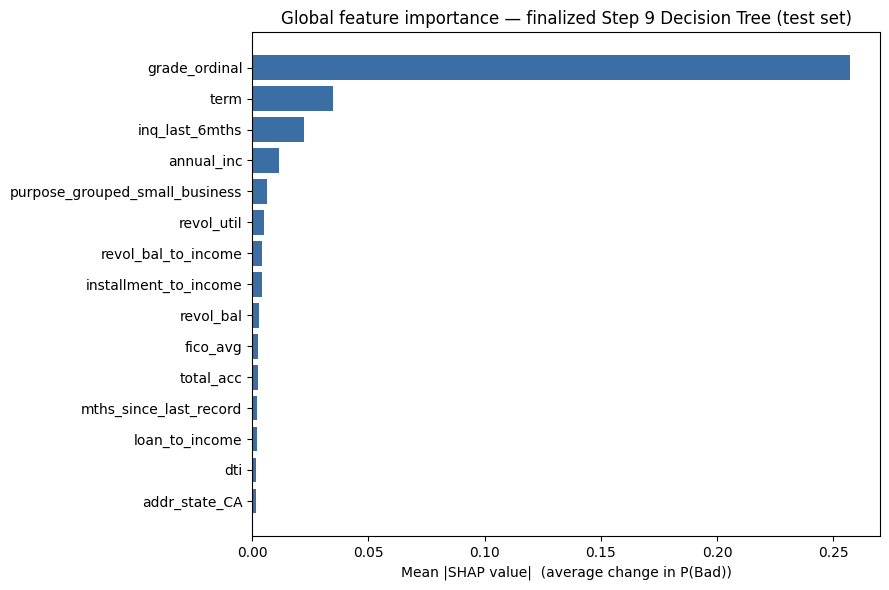

In [8]:
from IPython.display import display

mean_abs = sv_df.abs().mean().sort_values(ascending=False)
importance_df = pd.DataFrame({'feature': mean_abs.index, 'mean_abs_shap': mean_abs.values})
importance_df['mean_abs_shap_pp'] = importance_df['mean_abs_shap'] * 100
importance_df['share_of_total_%'] = 100 * importance_df['mean_abs_shap'] / importance_df['mean_abs_shap'].sum()
importance_df['cum_share_%'] = importance_df['share_of_total_%'].cumsum()
importance_df['source_feature'] = importance_df['feature'].map(feature_group)
importance_df['type'] = np.where(importance_df['feature'] == importance_df['source_feature'],
                                 'numeric / binary', 'one-hot category')
importance_df.insert(0, 'rank', np.arange(1, len(importance_df) + 1))

top15 = importance_df.head(15).reset_index(drop=True)
print("TOP 15 FEATURES BY MEAN |SHAP|  (units: change in P(Bad); pp = percentage points)")
display(top15[['rank', 'feature', 'mean_abs_shap', 'mean_abs_shap_pp', 'share_of_total_%', 'cum_share_%', 'type']]
        .round({'mean_abs_shap': 5, 'mean_abs_shap_pp': 3, 'share_of_total_%': 2, 'cum_share_%': 2}))

n_used = int((mean_abs > 0).sum())
print(f"\nFeatures with non-zero SHAP importance: {n_used} of {len(mean_abs)} "
      f"(the depth-{clf.get_depth()} tree never splits on the other {len(mean_abs) - n_used}).")
print(f"Top 15 account for {top15['cum_share_%'].iloc[-1]:.1f}% of total mean |SHAP|.")

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top15['feature'][::-1], top15['mean_abs_shap'][::-1], color='#3b6ea5')
ax.set_xlabel('Mean |SHAP value|  (average change in P(Bad))')
ax.set_title('Global feature importance — finalized Step 9 Decision Tree (test set)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'global_importance_top15.png'), dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Importance per ORIGINAL feature: sum the SHAP values of a feature's one-hot columns per loan, then take mean |.|
group_series = pd.Series([feature_group[f] for f in feature_names], index=feature_names)
grp_sv = sv_df.T.groupby(group_series).sum().T
grp_importance = grp_sv.abs().mean().sort_values(ascending=False)

grouped_df = pd.DataFrame({
    'rank': np.arange(1, len(grp_importance) + 1),
    'original_feature': grp_importance.index,
    'mean_abs_shap': grp_importance.values,
})
grouped_df['mean_abs_shap_pp'] = grouped_df['mean_abs_shap'] * 100
grouped_df['n_transformed_columns'] = grouped_df['original_feature'].map(group_series.value_counts())

print("TOP 15 ORIGINAL FEATURES (one-hot columns re-aggregated to their source feature)")
display(grouped_df.head(15).round({'mean_abs_shap': 5, 'mean_abs_shap_pp': 3}))

TOP 15 ORIGINAL FEATURES (one-hot columns re-aggregated to their source feature)


,rank,original_feature,mean_abs_shap,mean_abs_shap_pp,n_transformed_columns
0,1,grade_ordinal,0.25720,25.720,1
1,2,term,0.03485,3.485,1
2,3,inq_last_6mths,0.02222,2.222,1
3,4,annual_inc,0.01175,1.175,1
4,5,purpose_grouped,0.00719,0.719,12
5,6,revol_util,0.00531,0.531,1
6,7,revol_bal_to_income,0.00441,0.441,1
7,8,installment_to_income,0.00429,0.429,1
8,9,addr_state,0.00367,0.367,50
9,10,revol_bal,0.00277,0.277,1


### 6b. Sensitivity check — does the ranking depend on the SMOTE-balanced reference?

The default explainer measures effects relative to the *training-time (SMOTE-balanced)* node counts. As a robustness check,
we recompute SHAP with `feature_perturbation="interventional"` and a **background sample of real, un-resampled training loans**
(inference only — nothing is refit), on a 2,000-row random subset of the test set for speed (100 background loans). If the feature ranking is
broadly the same, the story below does not hinge on the balanced-reference choice. This is a stability check, not a second model.

In [10]:
RUN_SENSITIVITY_CHECK = True
SENS_N_BACKGROUND, SENS_N_EXPLAIN = 100, 2000

if RUN_SENSITIVITY_CHECK:
    try:
        rng = np.random.RandomState(RANDOM_STATE)
        Xt_train = np.asarray(fitted_pre.transform(X_train), dtype=float)     # transform only — no fit
        bg = Xt_train[rng.choice(Xt_train.shape[0], SENS_N_BACKGROUND, replace=False)]
        sub = rng.choice(Xt.shape[0], SENS_N_EXPLAIN, replace=False)

        expl_int = shap.TreeExplainer(clf, data=bg, feature_perturbation='interventional',
                                      model_output='probability')
        sv_int = bad_class_values(expl_int.shap_values(Xt[sub], check_additivity=False), len(sub), Xt.shape[1])
        base_int = float(np.atleast_1d(expl_int.expected_value)[-1])

        ma_path = np.abs(sv[sub]).mean(axis=0)
        ma_int = np.abs(sv_int).mean(axis=0)
        names_arr = np.array(feature_names)
        top_path = list(names_arr[np.argsort(-ma_path)[:15]])
        top_int = list(names_arr[np.argsort(-ma_int)[:15]])

        rho_rank = spearmanr(ma_path, ma_int)[0]
        overlap = len(set(top_path) & set(top_int))
        print(f"Baseline P(Bad): path-dependent = {base_value:.3f} (SMOTE-balanced reference)  |  "
              f"interventional on real training loans = {base_int:.3f}")
        print(f"Spearman rank correlation of mean|SHAP| across all {len(feature_names)} features: {rho_rank:.3f}")
        print(f"Top-15 overlap between the two reference choices: {overlap}/15")
        display(pd.DataFrame({'rank': range(1, 16), 'path_dependent (default)': top_path,
                              'interventional (real-train background)': top_int}))
    except Exception as e:                       # optional check — never block the main analysis
        print("Sensitivity check skipped:", type(e).__name__, e)

Baseline P(Bad): path-dependent = 0.500 (SMOTE-balanced reference)  |  interventional on real training loans = 0.210
Spearman rank correlation of mean|SHAP| across all 101 features: 0.997
Top-15 overlap between the two reference choices: 13/15


,rank,path_dependent (default),interventional (real-train background)
0,1,grade_ordinal,grade_ordinal
1,2,term,term
2,3,inq_last_6mths,inq_last_6mths
3,4,annual_inc,annual_inc
4,5,purpose_grouped_small_business,revol_util
5,6,revol_util,installment_to_income
6,7,installment_to_income,purpose_grouped_small_business
7,8,revol_bal_to_income,revol_bal
8,9,revol_bal,revol_bal_to_income
9,10,fico_avg,total_acc


## 7. SHAP summary plot

Each dot is one test loan. Position on the x-axis = that feature's SHAP value for that loan
(**right = pushes P(Bad) up, left = pushes it down**). Colour = the feature's value for that loan
(red = high, blue = low; for one-hot columns red = category present). Features are ordered by mean |SHAP|.

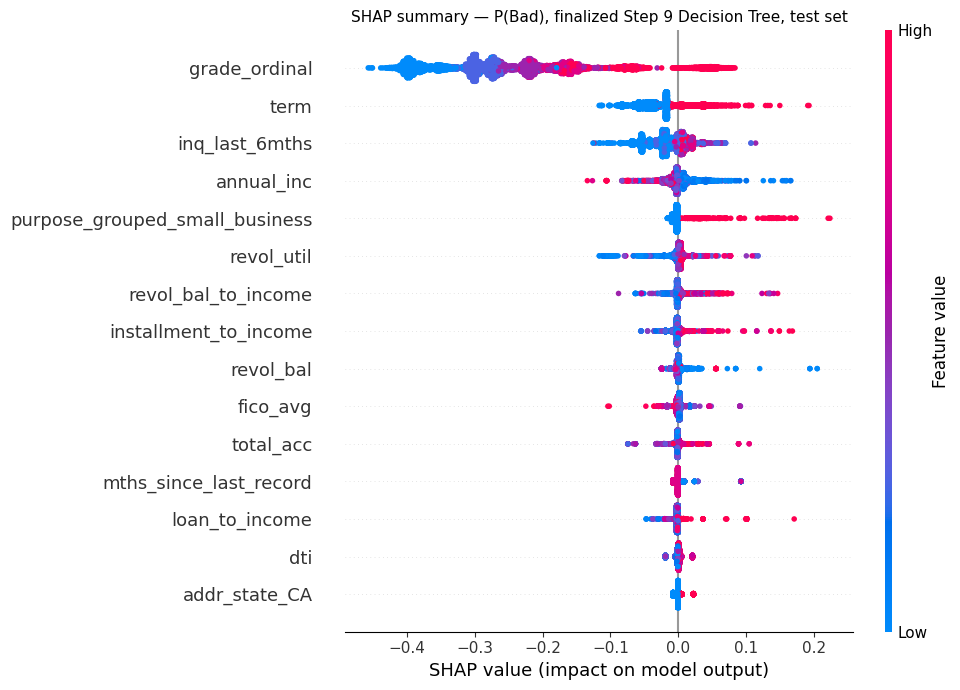

In [11]:
import warnings
np.random.seed(RANDOM_STATE)     # beeswarm jitter is random; fix it so the figure is reproducible
with warnings.catch_warnings():
    warnings.simplefilter('ignore', FutureWarning)
    shap.summary_plot(sv, Xt_df, max_display=15, plot_size=(10, 7), show=False)
plt.title('SHAP summary — P(Bad), finalized Step 9 Decision Tree, test set', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'shap_summary_beeswarm.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. Direction of the important features

Two complementary views for the top-15 features, both computed **from the SHAP values on the test set** (no assumptions):

1. **High-vs-low contrast** — mean SHAP for the lowest-quartile vs highest-quartile values of a feature (or `=1` vs `=0` for
   binary / one-hot columns), plus the Spearman correlation between the feature value and its SHAP value as a rough monotonicity hint.
2. **Binned table** (quintiles) for the top numeric features — shows *which value ranges* push toward Bad vs Good and whether the
   pattern is monotonic. A decision tree can produce step-like or non-monotonic patterns, so this matters.

A feature is reported as having **no clear direction** when the high-vs-low gap is smaller than 25% of its own mean |SHAP| (a scale-free rule); in the binned tables, “~neutral” means within ±10% of the feature's mean |SHAP|.

“Pushes toward Bad” means: for loans with these feature values, this model *adds* to its P(Bad) score. It says nothing about
whether changing the feature would change anyone's real-world repayment.

In [12]:
def direction_summary(feat):
    x = Xt_df[feat].to_numpy()
    s = sv_df[feat].to_numpy()
    uniq = np.unique(x)
    if uniq.size < 2:
        return None
    if uniq.size == 2:                                    # binary / one-hot
        kind = 'binary'
        low_m, high_m = (x == uniq[0]), (x == uniq[1])
        low_lab, high_lab = f"= {uniq[0]:g}", f"= {uniq[1]:g}"
    else:
        kind = 'continuous'
        q25, q75 = np.quantile(x, [0.25, 0.75])
        if q25 < q75:
            low_m, high_m = (x <= q25), (x >= q75)
            low_lab, high_lab = f"<= {q25:.4g} (lowest quartile)", f">= {q75:.4g} (highest quartile)"
        else:                                             # heavy ties (e.g. mostly-zero features)
            med = np.median(x)
            low_m, high_m = (x <= med), (x > med)
            low_lab, high_lab = f"<= {med:.4g}", f"> {med:.4g}"
    m_low = float(s[low_m].mean()) if low_m.any() else np.nan
    m_high = float(s[high_m].mean()) if high_m.any() else np.nan
    rho = float(spearmanr(x, s)[0]) if (np.unique(s).size > 1) else np.nan
    return {
        'feature': feat, 'kind': kind,
        'low_group': low_lab, 'high_group': high_lab,
        'n_low': int(low_m.sum()), 'n_high': int(high_m.sum()),
        'mean_shap_low_pp': m_low * 100, 'mean_shap_high_pp': m_high * 100,
        'spearman_value_vs_shap': rho,
    }

rows = [direction_summary(f) for f in top15['feature']]
direction_df = pd.DataFrame([r for r in rows if r is not None])
direction_df['is_onehot'] = direction_df['feature'].map(lambda f: feature_group[f] != f)
direction_df['diff_pp'] = direction_df['mean_shap_high_pp'] - direction_df['mean_shap_low_pp']
direction_df['feature_mean_abs_pp'] = direction_df['feature'].map(importance_df.set_index('feature')['mean_abs_shap_pp'])
# Scale-free rule: the high-vs-low gap must be at least 25% of the feature's own mean |SHAP| to count as a direction
direction_df['is_weak'] = direction_df['diff_pp'].abs() < 0.25 * direction_df['feature_mean_abs_pp']

def _label(r):
    if r['is_weak']:
        return 'no clear direction'
    if r['kind'] == 'binary':
        return 'value 1 -> toward Bad' if r['diff_pp'] > 0 else 'value 1 -> toward Good'
    return 'higher values -> toward Bad' if r['diff_pp'] > 0 else 'higher values -> toward Good'

direction_df['direction'] = direction_df.apply(_label, axis=1)
direction_df['shape_hint'] = np.where(direction_df['kind'] == 'binary', 'binary',
                              np.where(direction_df['spearman_value_vs_shap'].abs() >= 0.3,
                                       'roughly monotonic', 'mixed / non-monotonic'))

print("DIRECTION OF TOP-15 FEATURES (mean SHAP in percentage points of P(Bad))")
display(direction_df[['feature', 'low_group', 'mean_shap_low_pp', 'high_group', 'mean_shap_high_pp',
                      'spearman_value_vs_shap', 'direction', 'shape_hint']]
        .round({'mean_shap_low_pp': 2, 'mean_shap_high_pp': 2, 'spearman_value_vs_shap': 2}))

print("\nPLAIN-ENGLISH READ-OUT (model association only — not causation):")
for _, r in direction_df.iterrows():
    if r['is_onehot']:
        print(f" - {r['feature']}: category present -> {r['mean_shap_high_pp']:+.2f} pp vs absent -> {r['mean_shap_low_pp']:+.2f} pp "
              f"(one-hot category: descriptive of the model only; NOT a causal statement about that state/purpose/status)")
    elif r['kind'] == 'binary':
        print(f" - {r['feature']}: {r['high_group']} -> {r['mean_shap_high_pp']:+.2f} pp vs {r['low_group']} -> "
              f"{r['mean_shap_low_pp']:+.2f} pp  [{r['direction']}]")
    else:
        print(f" - {r['feature']}: values {r['high_group']} -> {r['mean_shap_high_pp']:+.2f} pp vs "
              f"{r['low_group']} -> {r['mean_shap_low_pp']:+.2f} pp  [{r['direction']}; {r['shape_hint']}, "
              f"rho={r['spearman_value_vs_shap']:.2f}]")

DIRECTION OF TOP-15 FEATURES (mean SHAP in percentage points of P(Bad))


,feature,low_group,mean_shap_low_pp,high_group,mean_shap_high_pp,spearman_value_vs_shap,direction,shape_hint
0,grade_ordinal,<= 2 (lowest quartile),-32.90,>= 3 (highest quartile),-16.41,0.95,higher values -> toward Bad,roughly monotonic
1,term,= 36,-3.88,= 60,1.69,0.72,value 1 -> toward Bad,binary
2,inq_last_6mths,<= 0 (lowest quartile),-3.34,>= 2 (highest quartile),1.20,0.82,higher values -> toward Bad,roughly monotonic
3,annual_inc,<= 4e+04 (lowest quartile),1.63,>= 8.3e+04 (highest quartile),-1.10,-0.70,higher values -> toward Good,roughly monotonic
4,purpose_grouped_small_business,= 0,-0.40,= 1,4.84,0.38,value 1 -> toward Bad,binary
5,revol_util,<= 0.2522 (lowest quartile),-0.89,>= 0.723 (highest quartile),0.52,0.78,higher values -> toward Bad,roughly monotonic
6,revol_bal_to_income,<= 0.0662 (lowest quartile),-0.31,>= 0.2822 (highest quartile),0.64,0.63,higher values -> toward Bad,roughly monotonic
7,installment_to_income,<= 0.03477 (lowest quartile),-0.36,>= 0.08686 (highest quartile),0.54,0.63,higher values -> toward Bad,roughly monotonic
8,revol_bal,<= 3491 (lowest quartile),0.47,>= 1.708e+04 (highest quartile),-0.19,-0.69,higher values -> toward Good,roughly monotonic
9,fico_avg,<= 687 (lowest quartile),0.20,>= 742 (highest quartile),-0.25,-0.69,higher values -> toward Good,roughly monotonic



PLAIN-ENGLISH READ-OUT (model association only — not causation):
 - grade_ordinal: values >= 3 (highest quartile) -> -16.41 pp vs <= 2 (lowest quartile) -> -32.90 pp  [higher values -> toward Bad; roughly monotonic, rho=0.95]
 - term: = 60 -> +1.69 pp vs = 36 -> -3.88 pp  [value 1 -> toward Bad]
 - inq_last_6mths: values >= 2 (highest quartile) -> +1.20 pp vs <= 0 (lowest quartile) -> -3.34 pp  [higher values -> toward Bad; roughly monotonic, rho=0.82]
 - annual_inc: values >= 8.3e+04 (highest quartile) -> -1.10 pp vs <= 4e+04 (lowest quartile) -> +1.63 pp  [higher values -> toward Good; roughly monotonic, rho=-0.70]
 - purpose_grouped_small_business: category present -> +4.84 pp vs absent -> -0.40 pp (one-hot category: descriptive of the model only; NOT a causal statement about that state/purpose/status)
 - revol_util: values >= 0.723 (highest quartile) -> +0.52 pp vs <= 0.2522 (lowest quartile) -> -0.89 pp  [higher values -> toward Bad; roughly monotonic, rho=0.78]
 - revol_bal_to_i

In [13]:
def binned_shap(feat, q=5):
    x = Xt_df[feat]
    bins = pd.qcut(x, q=q, duplicates='drop')
    out = (pd.DataFrame({'value_range': bins.astype(str), 'x': x.to_numpy(), 'shap_pp': sv_df[feat].to_numpy() * 100,
                         'order': bins.cat.codes.to_numpy()})
           .groupby(['order', 'value_range'], observed=True)
           .agg(n_loans=('x', 'size'), mean_value=('x', 'mean'), mean_shap_pp=('shap_pp', 'mean'))
           .reset_index().drop(columns='order'))
    band = 0.10 * float(importance_df.loc[importance_df['feature'] == feat, 'mean_abs_shap_pp'].iloc[0])   # neutral band
    out['pushes_toward'] = np.where(out['mean_shap_pp'] > band, 'Bad',
                             np.where(out['mean_shap_pp'] < -band, 'Good', '~neutral'))
    return out

numeric_top = [f for f in top15['feature']
               if feature_group[f] == f and np.unique(Xt_df[f]).size > 2][:8]

print("BINNED SHAP FOR THE TOP NUMERIC FEATURES (quintiles of the feature's value on the test set)")
for f in numeric_top:
    print(f"\n{f}")
    display(binned_shap(f).round({'mean_value': 3, 'mean_shap_pp': 2}))

BINNED SHAP FOR THE TOP NUMERIC FEATURES (quintiles of the feature's value on the test set)

grade_ordinal


,value_range,n_loans,mean_value,mean_shap_pp,pushes_toward
0,"(0.999, 2.0]",4571,1.548,-32.90,Good
1,"(2.0, 3.0]",1751,3.000,-22.03,Good
2,"(3.0, 4.0]",1099,4.000,-17.05,Good
3,"(4.0, 7.0]",977,5.459,-5.61,Good



inq_last_6mths


,value_range,n_loans,mean_value,mean_shap_pp,pushes_toward
0,"(-0.001, 1.0]",6106,0.361,-2.36,Good
1,"(1.0, 2.0]",1167,2.000,1.22,Bad
2,"(2.0, 32.0]",1125,4.015,1.17,Bad



annual_inc


...

,value_range,n_loans,mean_value,mean_shap_pp,pushes_toward
0,"(-0.0005110000000000001, 0.0304]",1680,0.020,-0.36,Good
1,"(0.0304, 0.048]",1679,0.039,-0.34,Good
2,"(0.048, 0.0671]",1680,0.057,-0.36,Good
3,"(0.0671, 0.0957]",1679,0.080,0.06,Bad
4,"(0.0957, 0.298]",1680,0.129,0.63,Bad



revol_bal


,value_range,n_loans,mean_value,mean_shap_pp,pushes_toward
0,"(-0.001, 2645.2]",1680,1069.823,0.58,Bad
1,"(2645.2, 6401.4]",1679,4455.939,0.03,Bad
2,"(6401.4, 11345.2]",1680,8691.557,0.02,~neutral
3,"(11345.2, 19883.8]",1679,15126.285,-0.17,Good
4,"(19883.8, 952013.0]",1680,40319.770,-0.17,Good



fico_avg


,value_range,n_loans,mean_value,mean_shap_pp,pushes_toward
0,"(611.999, 682.0]",1920,671.638,0.18,Bad
1,"(682.0, 702.0]",1752,694.646,0.32,Bad
2,"(702.0, 722.0]",1499,714.585,-0.06,Good
3,"(722.0, 747.0]",1607,736.119,-0.07,Good
4,"(747.0, 822.0]",1620,771.790,-0.28,Good


## 9. One individual explanation

**Selection rule (fixed in advance, not cherry-picked, and without looking at the true label):** among the test loans that the
model flags as Bad (predicted class 1), take the loan whose P(Bad) is closest to the *median* P(Bad) of the flagged loans; ties
are broken by test-set order. This gives a typical flagged loan rather than an extreme one. Its true outcome is printed for
reference only and plays no part in the explanation. Set `OVERRIDE_POSITION` to any row position to explain a different loan.

Feature values shown are the values the tree actually saw (numeric = median-imputed if the original was missing; one-hot =
whether that category is active).

In [14]:
OVERRIDE_POSITION = None          # e.g. 123 to explain the 124th test row instead

flagged = np.where(y_pred_dt == 1)[0]
if OVERRIDE_POSITION is not None:
    pos = int(OVERRIDE_POSITION)
    rule = f"manually selected row position {pos}"
else:
    pool = flagged if len(flagged) > 0 else np.arange(len(y_proba_dt))
    target_p = float(np.median(y_proba_dt[pool]))
    pos = int(pool[np.argmin(np.abs(y_proba_dt[pool] - target_p))])
    rule = ("closest to the median P(Bad) among loans flagged as Bad "
            f"(n_flagged={len(flagged):,}, median P(Bad)={target_p:.3f}); ties -> first in test-set order")

p_bad = float(y_proba_dt[pos])
pct_rank = 100 * float((y_proba_dt <= p_bad).mean())
print("Selection rule:", rule)
print(f"Test-set row position: {pos}   |   original DataFrame index: {X_test.index[pos]}")
print(f"Model P(Bad):          {p_bad:.4f}   (predicted class: {'Bad' if y_pred_dt[pos] == 1 else 'Good'} at the 0.5 cut-off)")
print(f"  baseline P(Bad):     {base_value:.4f}  ->  net SHAP push = {100 * sv[pos].sum():+.2f} pp")
print(f"  additivity check:    baseline + sum(SHAP) = {base_value + sv[pos].sum():.4f}  (model output {p_bad:.4f})")
print(f"  score percentile:    this loan's P(Bad) is >= {pct_rank:.1f}% of test loans")
print(f"  true outcome (reference only, not used in the explanation): {'Bad (defaulted)' if y_test.iloc[pos] == 1 else 'Good (repaid)'}")
print("  NOTE: P(Bad) is a SMOTE-trained model score, not a calibrated default probability "
      f"(real test Bad rate = {y_test.mean():.3f}).")

contrib = pd.DataFrame({
    'feature': feature_names,
    'source_feature': [feature_group[f] for f in feature_names],
    'value_seen_by_tree': Xt[pos],
    'shap': sv[pos],
})
contrib['effect_pp'] = contrib['shap'] * 100
contrib['type'] = np.where(contrib['feature'] == contrib['source_feature'], 'numeric / binary', 'one-hot category')
imputed_flag = []
for f, src, t in zip(contrib['feature'], contrib['source_feature'], contrib['type']):
    imputed_flag.append(bool(pd.isna(X_test.iloc[pos][src])) if t == 'numeric / binary' else False)
contrib['was_missing_and_imputed'] = imputed_flag
contrib['value_display'] = [
    (('category ACTIVE' if v == 1 else 'category not active') if t == 'one-hot category' else f"{v:.4g}")
    for v, t in zip(contrib['value_seen_by_tree'], contrib['type'])
]

up = contrib[contrib['shap'] > 0].sort_values('shap', ascending=False).head(6)
down = contrib[contrib['shap'] < 0].sort_values('shap').head(6)
cols = ['feature', 'value_display', 'effect_pp', 'was_missing_and_imputed']

print("\nMAIN FEATURES PUSHING RISK UP (toward Bad):")
display(up[cols].round({'effect_pp': 2}).reset_index(drop=True))
print("MAIN FEATURES PUSHING RISK DOWN (toward Good):")
display(down[cols].round({'effect_pp': 2}).reset_index(drop=True))

others = contrib.drop(index=list(up.index) + list(down.index))
print(f"All {len(others)} remaining features net effect: {others['effect_pp'].sum():+.2f} pp")

Selection rule: closest to the median P(Bad) among loans flagged as Bad (n_flagged=434, median P(Bad)=0.539); ties -> first in test-set order
Test-set row position: 2   |   original DataFrame index: 5693
Model P(Bad):          0.5386   (predicted class: Bad at the 0.5 cut-off)
  baseline P(Bad):     0.5000  ->  net SHAP push = +3.86 pp
  additivity check:    baseline + sum(SHAP) = 0.5386  (model output 0.5386)
  score percentile:    this loan's P(Bad) is >= 98.9% of test loans
  true outcome (reference only, not used in the explanation): Good (repaid)
  NOTE: P(Bad) is a SMOTE-trained model score, not a calibrated default probability (real test Bad rate = 0.153).

MAIN FEATURES PUSHING RISK UP (toward Bad):


,feature,value_display,effect_pp,was_missing_and_imputed
0,grade_ordinal,6,4.03,False
1,term,60,0.79,False
2,installment_to_income,0.1224,0.49,False
3,revol_util,0.988,0.35,False
4,open_acc,6,0.13,False
5,fico_avg,712,0.11,False


MAIN FEATURES PUSHING RISK DOWN (toward Good):


,feature,value_display,effect_pp,was_missing_and_imputed
0,inq_last_6mths,0,-0.94,False
1,total_acc,25,-0.40,False
2,loan_to_income,0.3717,-0.19,False
3,purpose_grouped_small_business,category not active,-0.16,False
4,installment,748.9,-0.12,False
5,revol_bal,2.372e+04,-0.09,False


All 89 remaining features net effect: -0.14 pp


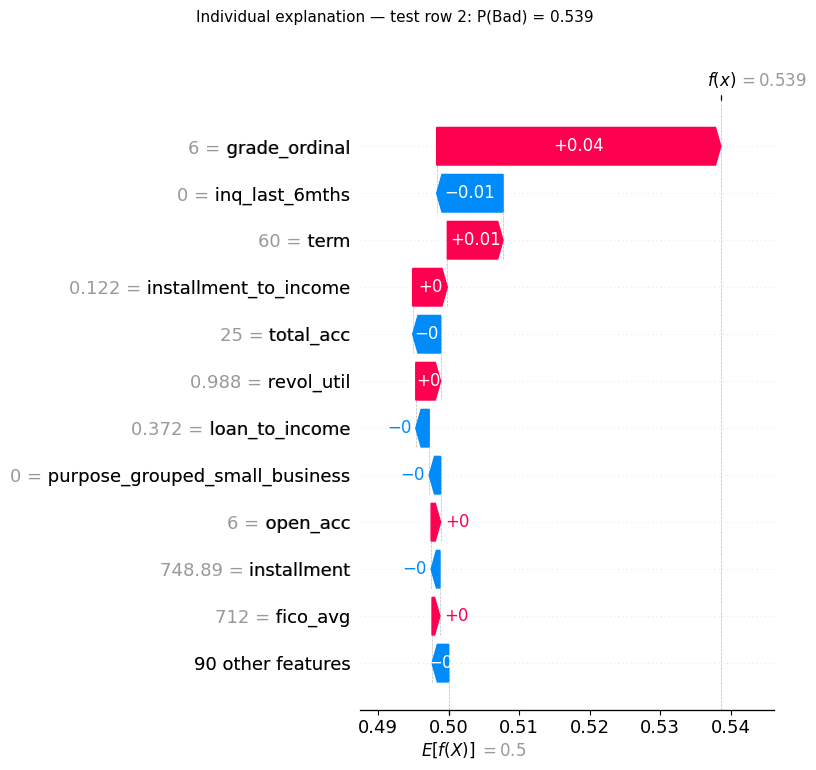

In [15]:
explanation = shap.Explanation(values=sv[pos], base_values=base_value, data=Xt[pos], feature_names=feature_names)
shap.plots.waterfall(explanation, max_display=12, show=False)
plt.gcf().suptitle(f"Individual explanation — test row {pos}: P(Bad) = {p_bad:.3f}", fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'individual_waterfall.png'), dpi=150, bbox_inches='tight')
plt.show()

## 10. Business interpretation — connecting features to credit-risk concepts

The table maps each top-15 feature to the credit-risk concept it represents, states the **direction a credit analyst would
normally expect** (only where there is a well-established prior), and compares it with the **direction the model actually
uses** (Section 8). Agreement is reassuring; disagreement is a prompt to investigate — correlated features sharing credit,
median-imputed values, interactions, or an artifact of a single tree — **not** a discovery about borrowers.

In [16]:
# concept, expected sign of "higher value => higher default risk" (+1 / -1 / None = no firm prior), note
CONCEPT_MAP = {
    'loan_amnt':               ('Loan size', +1, 'Larger principal = larger exposure and payment for the same borrower.'),
    'term':                    ('Loan term', +1, 'Longer terms mean longer exposure to income shocks.'),
    'int_rate':                ('Interest rate / risk-based pricing', +1,
                                'The rate is set by the lender from its own risk view (grade, FICO), so it partly encodes risk already assessed; it also raises the payment burden.'),
    'installment':             ('Payment size', +1, 'Larger required payments strain cash flow.'),
    'annual_inc':              ('Income / repayment capacity', -1, 'More income = more capacity to service debt.'),
    'dti':                     ('Debt burden (DTI)', +1, 'A larger share of income already committed to debt leaves less slack.'),
    'inq_last_6mths':          ('Recent credit seeking', +1, 'Many recent inquiries can signal credit stress.'),
    'mths_since_last_delinq':  ('Delinquency recency', None,
                                'Missing (= never delinquent) was median-imputed, so this column mixes "no delinquency" with a real recency.'),
    'mths_since_last_record':  ('Public-record recency', None,
                                'Missing (= no record) was median-imputed, so this column mixes "no record" with a real recency.'),
    'open_acc':                ('Number of open accounts', None, 'Ambiguous: breadth of credit can signal access or over-extension.'),
    'revol_bal':               ('Revolving balance', +1, 'Higher revolving balances = more unsecured debt.'),
    'revol_util':              ('Credit utilization', +1, 'High utilization of available revolving credit is a classic stress signal.'),
    'total_acc':               ('Credit depth (total accounts)', None, 'Ambiguous: more accounts can mean experience or more leverage.'),
    'delinq_amnt':             ('Delinquencies (amount past due)', +1, 'Amounts already past due indicate current payment trouble.'),
    'pub_rec_bankruptcies':    ('Public records / bankruptcies', +1, 'Prior bankruptcy is a strong adverse credit-history signal.'),
    'credit_history_months':   ('Credit history length', -1, 'Longer histories give more evidence of repayment behaviour.'),
    'loan_to_income':          ('Loan size relative to income', +1, 'Requested amount as a multiple of income.'),
    'installment_to_income':   ('Payment burden', +1, 'Monthly payment as a share of income.'),
    'revol_bal_to_income':     ('Revolving debt burden', +1, 'Revolving debt as a multiple of income.'),
    'open_acc_ratio':          ('Open / total accounts', None, 'Ambiguous without further context.'),
    'fico_avg':                ('FICO credit score', -1, 'Higher scores summarize better past repayment behaviour.'),
    'grade_ordinal':           ('Lender risk grade', None,
                                'Direction depends on how the grade was ordinally encoded — confirm the encoding before reading it.'),
    'emp_length_years':        ('Employment stability', -1, 'Weak prior: longer tenure may proxy income stability.'),
    'has_public_record':       ('Public record flag', +1, 'Adverse credit-history flag.'),
    'has_delinquency':         ('Delinquency flag', +1, 'Adverse credit-history flag.'),
    'pub_rec_bankruptcies_missing': ('Missingness indicator', None, 'Records that data were missing, not a borrower attribute per se.'),
    'revol_util_missing':      ('Missingness indicator', None, 'Records that data were missing, not a borrower attribute per se.'),
    'emp_length_missing':      ('Missingness indicator', None, 'Records that data were missing, not a borrower attribute per se.'),
    'is_income_verified':      ('Income verification', None,
                                'No firm prior: verification is chosen by the lender and can be applied to riskier/larger loans (selection effect).'),
    'verification_status':     ('Verification status (categorical)', None, 'Categorical — descriptive only.'),
    'addr_state':              ('Borrower state (categorical)', None, 'Categorical — descriptive only; likely a proxy for unmeasured regional factors.'),
    'dti_bin':                 ('DTI bucket (categorical)', None, 'Derived from dti, so it overlaps with the numeric DTI column.'),
    'home_ownership_grouped':  ('Home ownership (categorical)', None, 'Categorical — descriptive only.'),
    'purpose_grouped':         ('Loan purpose (categorical)', None, 'Categorical — descriptive only.'),
}

rows = []
for _, r in direction_df.iterrows():
    grp = feature_group[r['feature']]
    concept, exp_sign, note = CONCEPT_MAP.get(grp, ('(unmapped)', None, ''))
    if r['is_weak']:
        obs, verdict = 'no clear direction', 'weak / unclear effect'
    else:
        obs_sign = +1 if r['diff_pp'] > 0 else -1
        obs = ('higher / present -> Bad' if obs_sign > 0 else 'higher / present -> Good')
        if r['is_onehot']:
            verdict = 'descriptive only (categorical; not causal)'
        elif exp_sign is None:
            verdict = 'no firm prior'
        elif obs_sign == exp_sign:
            verdict = 'consistent with credit-risk intuition'
        else:
            verdict = 'CONTRARY to intuition -> investigate'
    rows.append({'rank': int(top15.loc[top15['feature'] == r['feature'], 'rank'].iloc[0]),
                 'feature': r['feature'], 'credit-risk concept': concept,
                 'expected (higher->risk)': {1: 'up', -1: 'down', None: '-'}[exp_sign],
                 'model uses': obs, 'verdict': verdict, 'note': note})
business_df = pd.DataFrame(rows)
pd.set_option('display.max_colwidth', 90)
display(business_df)

,rank,feature,credit-risk concept,expected (higher->risk),model uses,verdict,note
0,1,grade_ordinal,Lender risk grade,-,higher / present -> Bad,no firm prior,Direction depends on how the grade was ordinally encoded — confirm the encoding before...
1,2,term,Loan term,up,higher / present -> Bad,consistent with credit-risk intuition,Longer terms mean longer exposure to income shocks.
2,3,inq_last_6mths,Recent credit seeking,up,higher / present -> Bad,consistent with credit-risk intuition,Many recent inquiries can signal credit stress.
3,4,annual_inc,Income / repayment capacity,down,higher / present -> Good,consistent with credit-risk intuition,More income = more capacity to service debt.
4,5,purpose_grouped_small_business,Loan purpose (categorical),-,higher / present -> Bad,descriptive only (categorical; not causal),Categorical — descriptive only.
5,6,revol_util,Credit utilization,up,higher / present -> Bad,consistent with credit-risk intuition,High utilization of available revolving credit is a classic stress signal.
6,7,revol_bal_to_income,Revolving debt burden,up,higher / present -> Bad,consistent with credit-risk intuition,Revolving debt as a multiple of income.
7,8,installment_to_income,Payment burden,up,higher / present -> Bad,consistent with credit-risk intuition,Monthly payment as a share of income.
8,9,revol_bal,Revolving balance,up,higher / present -> Good,CONTRARY to intuition -> investigate,Higher revolving balances = more unsecured debt.
9,10,fico_avg,FICO credit score,down,higher / present -> Good,consistent with credit-risk intuition,Higher scores summarize better past repayment behaviour.


In [17]:
# Overlap among the top numeric features: SHAP splits credit between correlated inputs, so read them as a family.
num_top = [f for f in top15['feature'] if feature_group[f] == f and np.unique(Xt_df[f]).size > 2]
corr = Xt_df[num_top].corr(method='spearman')
pairs = [(a, b, corr.loc[a, b]) for i, a in enumerate(num_top) for b in num_top[i + 1:] if abs(corr.loc[a, b]) >= 0.6]
print("Strongly correlated pairs among the top numeric features (|Spearman rho| >= 0.6, on the test set):")
if pairs:
    display(pd.DataFrame(pairs, columns=['feature_a', 'feature_b', 'spearman_rho']).sort_values(
        'spearman_rho', key=lambda s: -s.abs()).round(2).reset_index(drop=True))
else:
    print("  none")

Strongly correlated pairs among the top numeric features (|Spearman rho| >= 0.6, on the test set):


,feature_a,feature_b,spearman_rho
0,installment_to_income,loan_to_income,0.95
1,revol_bal_to_income,revol_bal,0.87
2,grade_ordinal,fico_avg,-0.73


### How to read the business table (framework — the *observed* directions are in the tables above)

| Credit-risk concept | Features in this model | What the model's use of them can and cannot tell you |
|---|---|---|
| **Debt burden** | `dti`, `dti_bin_*`, `revol_bal`, `revol_bal_to_income`, `installment_to_income` | If these push toward Bad at high values, the model has learned that stretched borrowers score riskier — the standard affordability story. It does not show that lowering DTI would prevent a default. |
| **Interest rate / pricing** | `int_rate`, `grade_ordinal`, `term` | These are **lender-assigned at origination** and already summarize the lender's own risk assessment. Their importance largely says “the lender's pricing is informative”, not “high rates cause default”. Higher rates also raise payments, so some real effect is plausible but cannot be separated here. |
| **FICO / credit history** | `fico_avg`, `credit_history_months`, `total_acc`, `open_acc` | Bureau-based summaries of past repayment behaviour. Expected: better scores / longer history → lower risk. |
| **Utilization** | `revol_util`, `revol_util_missing` | High utilization is a classic stress signal; the `_missing` flag only marks data absence. |
| **Delinquencies / public records** | `has_delinquency`, `delinq_amnt`, `pub_rec_bankruptcies`, `has_public_record`, `mths_since_last_*` | Adverse history flags. `mths_since_last_*` were median-imputed when missing (= never occurred), so their raw direction is hard to interpret alone. |
| **Income** | `annual_inc`, `loan_to_income`, `is_income_verified` | Capacity to repay. `is_income_verified` is a lender decision and can be confounded (selection). |
| **Loan size** | `loan_amnt`, `installment`, `loan_to_income` | Exposure and payment size. |
| **State / purpose / home ownership / verification (one-hot)** | `addr_state_*`, `purpose_grouped_*`, `home_ownership_grouped_*`, `verification_status_*` | **Do not interpret as causal.** These are sparse category indicators that can proxy unmeasured regional, product, or lender-process differences. Report them as “the model uses X”, never “X causes default”. |

## 11. Interview-defensible interpretation guide

**What SHAP does say**
- For *this fitted tree*, how much each feature moved each test loan's P(Bad) relative to a reference, and that the pieces add up exactly to the model's output (verified in Section 5).
- Which features the model relies on most (global ranking) and in which value ranges it pushes toward Bad vs Good.

**What SHAP does not say**
- **Not causal.** SHAP attributes a *model's output* to its *inputs*. It is not an intervention effect. “High `int_rate` pushes the score up” ≠ “raising someone's rate causes default”; the rate, grade and FICO are all lender-side summaries of the same underlying risk.
- **Not a statement about all models.** A different tree, another random split, or a random forest can distribute credit differently. A single decision tree is a high-variance model, so the ranking is a description of *this* tree.
- **Correlated features share credit.** `int_rate`, `grade_ordinal`, `fico_avg` (and `term`, DTI and its ratios) overlap heavily; the split of importance among them is partly arbitrary. Read them as a family (see the correlation table in Section 10).
- **One-hot categories are not causal and are fragmented.** State/purpose/home-ownership columns are many small indicators; use the per-original-feature table for the honest total, and never describe a state or purpose as “causing” risk.
- **Probabilities are model scores.** The tree was fitted on SMOTE-balanced data, so P(Bad) is not a calibrated default probability, and the baseline (~0.50) is a balanced reference rather than the real ~15% base rate. The interventional sensitivity check (6b) shows whether the ranking depends on that choice.
- **The model is modest.** On the test set it has ROC-AUC 0.667 and recall 0.108 for Bad at the default cut-off (Step 10). SHAP explains what the model *learned*, and a weakly predictive model's explanations should not be over-read as facts about borrowers.
- **Imputation matters.** Missing values were median-imputed (numeric) or mode-imputed (categorical), so `mths_since_last_*` and `*_missing` features can mix “not applicable” with real values.

**One-sentence answer to “what drives the model?”** — “The tree relies mainly on the features in the top-15 table; their direction is largely consistent with standard credit-risk intuition where the table says so, and where it does not, correlated features, imputation, or single-tree instability are the first things I would check — and none of this is a causal claim.”

## 12. Summary and saved artifacts

In [18]:
importance_df.to_csv(os.path.join(OUTPUT_DIR, 'global_importance_all_features.csv'), index=False)
grouped_df.to_csv(os.path.join(OUTPUT_DIR, 'global_importance_by_original_feature.csv'), index=False)
direction_df.to_csv(os.path.join(OUTPUT_DIR, 'direction_top15.csv'), index=False)
business_df.to_csv(os.path.join(OUTPUT_DIR, 'business_interpretation_top15.csv'), index=False)
contrib.sort_values('shap', key=lambda s: -s.abs()).to_csv(os.path.join(OUTPUT_DIR, 'individual_explanation_row.csv'), index=False)

print("=" * 70)
print("STEP 14 SUMMARY — SHAP explainability of the finalized Step 9 Decision Tree")
print("=" * 70)
print(f"Model explained:            {MODEL_SOURCE}")
print(f"Model:                      preprocessing -> SMOTE -> DecisionTreeClassifier "
      f"(entropy, max_depth=8, min_samples_leaf=5, min_samples_split=2, random_state=42)")
print(f"Explainer:                  shap.TreeExplainer (tree_path_dependent), shap {shap.__version__}")
print(f"Explained data:             X_test only, {Xt.shape[0]:,} loans x {Xt.shape[1]} transformed features")
print(f"SHAP shape:                 {sv.shape};  additivity max error {max_err:.2e}")
print(f"Integrity / reference:      {'ALL PASS' if integrity_ok else 'FAIL'} / {'ALL PASS' if reference_ok else 'FAIL'}")
print()
print("Top 5 features by mean |SHAP|:")
for _, r in top15.head(5).iterrows():
    print(f"  {int(r['rank'])}. {r['feature']:<28s} {r['mean_abs_shap_pp']:.3f} pp  ({r['share_of_total_%']:.1f}% of total)")
print()
print("Not done (by design): retraining/tuning, text/TF-IDF, Step 13 combined model, Step 8 diagnostic arrays, "
      "new models, new feature engineering, NLP, GenAI.")
print(f"Artifacts saved to: {OUTPUT_DIR}")
print(sorted(os.listdir(OUTPUT_DIR)))

STEP 14 SUMMARY — SHAP explainability of the finalized Step 9 Decision Tree
Model explained:            rebuilt from recorded Step 9 best_params_ and fitted once on X_train/y_train (no search)
Model:                      preprocessing -> SMOTE -> DecisionTreeClassifier (entropy, max_depth=8, min_samples_leaf=5, min_samples_split=2, random_state=42)
Explainer:                  shap.TreeExplainer (tree_path_dependent), shap 0.52.0
Explained data:             X_test only, 8,398 loans x 101 transformed features
SHAP shape:                 (8398, 101);  additivity max error 4.44e-16
Integrity / reference:      ALL PASS / ALL PASS

Top 5 features by mean |SHAP|:
  1. grade_ordinal                25.720 pp  (68.5% of total)
  2. term                         3.485 pp  (9.3% of total)
  3. inq_last_6mths               2.222 pp  (5.9% of total)
  4. annual_inc                   1.175 pp  (3.1% of total)
  5. purpose_grouped_small_business 0.629 pp  (1.7% of total)

Not done (by design): retraini